<a href="https://colab.research.google.com/github/thornton330j/IS-4487/blob/main/Assignments/assignment_09_ThorntonJackson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

In [1]:
# Add code here 🔧
import pandas as pd

# URL for the hotels.csv
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)

# Display
display(df.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### ✍️ Your Response: 🔧
1. The agent and company columns have several NaN  entries, indicating missing data in those fields. One booking has a lead time of 737 days, which is exceptionally long and indicates an outlier.
The first two bookings show an adr of 0. This is unusual for a hotel booking and could represent potential data entry errors. This column might require special handling or investigation.


## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Create total nights df
df['total_nights']=df['stays_in_weekend_nights']+df['stays_in_week_nights']

# Select features for clustering
selected_features=['lead_time','adults','adr','total_of_special_requests','total_nights']
df_selected_features=df[selected_features].copy()

# Drop rows with missing values
df_selected_features=df_selected_features.dropna().reset_index(drop=True)

# Show
print("Shape after dropping NaNs:",df_selected_features.shape)

# Initialize Sscaler
scaler = StandardScaler()

# Fit and transform
df_scaled = scaler.fit_transform(df_selected_features)

# Convert the scaled array
df_scaled = pd.DataFrame(df_scaled, columns=selected_features)

print("Scaled:")
display(df_scaled.head())

Shape after dropping NaNs: (119390, 5)
Scaled:


,lead_time,adults,adr,total_of_special_requests,total_nights
0,2.227051,0.247897,-2.015038,-0.720694,-1.340370
1,5.923385,0.247897,-2.015038,-0.720694,-1.340370
2,-0.907814,-1.478447,-0.530935,-0.720694,-0.949352
3,-0.851667,-1.478447,-0.530935,-0.720694,-0.949352
4,-0.842309,0.247897,-0.075810,0.540666,-0.558334


### ✍️ Your Response: 🔧
1. I selected lead_time, adults, adr, total_of_special_requests, and total_nights. I chose these features because they directly reflect key aspects of a customer's habits, preferences, and demographics. These are key for creating customer segments for a hotel business

2. I expected to find segments like families, budget travelers, luxury travelers, and professionals (e.g. travelling for business). These patterns are expected because they are common guest types for hotels.


## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



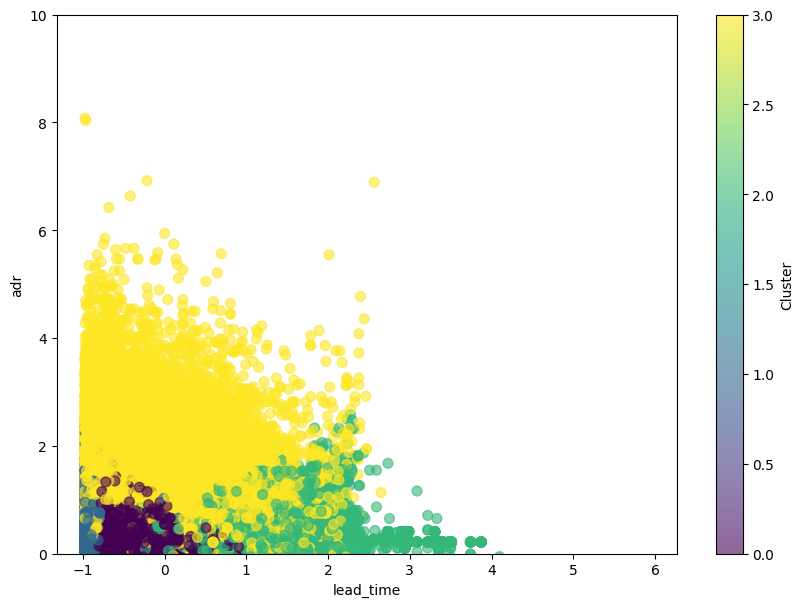

In [13]:
# Add code here 🔧
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Initialize KMeans (k = 4)
kmeans=KMeans(n_clusters=4,random_state=42,n_init='auto')

# Fit the model to the scaled data
kmeans.fit(df_scaled)

# Predict the clusters
df_scaled['cluster']=kmeans.predict(df_scaled)

# Visualize using scatterplot
plt.figure(figsize=(10,7))
plt.scatter(df_scaled['lead_time'],df_scaled['adr'],c=df_scaled['cluster'],cmap='viridis',s=50,alpha=0.6)
plt.xlabel('lead_time')
plt.ylabel('adr')
plt.colorbar(label='Cluster')

#Limit scatterplot to reduce outlier effect
plt.ylim(0,10)

# Show scatterplot
plt.show()

### ✍️ Your Response: 🔧
1. I chose a k value of 4. I chose 4 to create a reasonable number of distinct customer segments for a hotel business.
2. The four distinct clusters show lower lead_time and varying adr, higher lead_time and higher adr,
very low adr and a range of lead_time, and moderate lead_time and adr.


## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


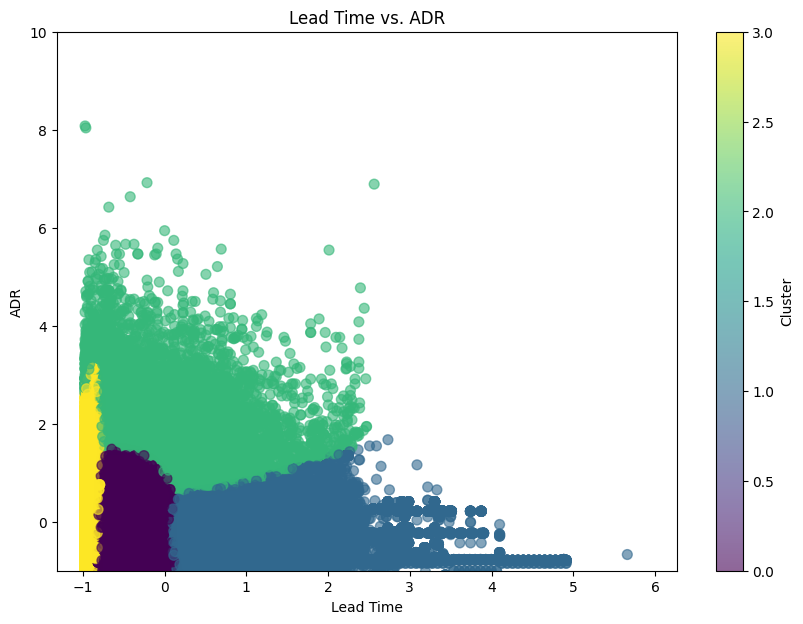

In [15]:
# Add your code here
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

# Select features for GMM
gmm_features=df_scaled[['lead_time','adr']]

# Initialize GMM
gmm=GaussianMixture(n_components=4,random_state=42,n_init=10)

# Fit the GMM to scaled data
gmm.fit(gmm_features)

# Predict soft clusters
gmm_probs=gmm.predict_proba(gmm_features)

# Assign each data point to the cluster
df_scaled['gmm_cluster']=np.argmax(gmm_probs, axis=1)

# Visualize clusters
plt.figure(figsize=(10, 7))
plt.scatter(df_scaled['lead_time'],df_scaled['adr'],c=df_scaled['gmm_cluster'],cmap='viridis',s=50,alpha=0.6)
plt.xlabel('Lead Time')
plt.ylabel('ADR')
plt.colorbar(label='Cluster')
plt.title('Lead Time vs. ADR')

# Limit scatterplot to reduce outlier effect
plt.ylim(-1, 10)

# Show scatterplot
plt.show()

### ✍️ Your Response: 🔧
1. The GMM clusters are more elliptical and less rigidly defined than the K-Means. GMM, models clusters to allow for more flexible shapes and potentially overlapping regions.

2. GMM is better for understanding customer uncertainty and when segments have varying shapes, densities, or overlap. This allows for more nuanced insights into complex customer behaviors.


## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [ ]:
# Add code here 🔧

### ✍️ Your Response: 🔧
1.

2.


## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [ ]:
# Add code here 🔧

### ✍️ Your Response: 🔧
1.

2.


## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1.

2.

3.

4.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [ ]:
!jupyter nbconvert --to html "assignment_09_ThorntonJackson.ipynb"